## Experiment 3 qubit Tutorial

In [16]:
# Import required libraries
import numpy as np
import optax
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.gates import *
from qsopt.core.experiment.experiment import Experiment
from qsopt.core.loss_functions import DetectionMetric

# Suppress warnings for cleaner output
#import warnings
#warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [17]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 3

interactions = [QubitInteraction(
    qubit_indices=(i, j),
    interaction_type=InteractionType.XX,
    chi=0.1
) for i in range(n_qubits) for j in range(n_qubits) if i!=j ]

physical_constants = PhysicalConstants(
    n_qubits=n_qubits,
    chi= 2.0*gm,
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=interactions
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=2
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-5.0, 5.0])/inverse_pulse_width)
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=0.001,
    dephasing=0.001,
    relaxation=0.001
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          3
  Cavity levels:             2
  Qubit levels:         [2, 2, 2]
  Field levels:              2
  Total dimension:          32
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   6 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
    [1] Qubits (0, 2): sx-sx, χ=0.1000
    [2] Qubits (0, 1): sx-sx, χ=0.1000
    [3] Qubits (1, 2): sx-sx, χ=0.1000
    [4] Qubits (0, 2): sx-sx, χ=0.1000
    [5] Qubits (1, 2): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-5.0, 5.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.001, 0.001, 0.001]
  Dephasing rate:       [0.001, 0.001, 0.001]
  Relaxation rate:      [0.001, 0.001, 0.001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For three-qubit experiments, we test multiple rotation layers and different circuit configurations

In [18]:
# Create three-qubit circuits with layered rotations

ini_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/2)
ini_circuit.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/2)

print(ini_circuit)
print(fin_circuit)

ini_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/4)
ini_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
ini_circuit_entangled.add_layer(gate_type = RYGate, parameters= np.pi/4)
ini_circuit_entangled.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/4)
fin_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
fin_circuit_entangled.add_layer(gate_type=RYGate, parameters= -np.pi/4)

print(ini_circuit_entangled)
print(fin_circuit_entangled)

QuantumCircuit(3 qubits, 6 gates)
  0: RY[0](param=1.571)
  1: RY[1](param=1.571)
  2: RY[2](param=1.571)
  3: RZ[0](param=1.047)
  4: RZ[1](param=1.047)
  5: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 3 gates)
  0: RY[0](param=-1.571)
  1: RY[1](param=-1.571)
  2: RY[2](param=-1.571)
QuantumCircuit(3 qubits, 12 gates)
  0: RY[0](param=0.785)
  1: RY[1](param=0.785)
  2: RY[2](param=0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=0.785)
  7: RY[1](param=0.785)
  8: RY[2](param=0.785)
  9: RZ[0](param=1.047)
  10: RZ[1](param=1.047)
  11: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 9 gates)
  0: RY[0](param=-0.785)
  1: RY[1](param=-0.785)
  2: RY[2](param=-0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=-0.785)
  7: RY[1](param=-0.785)
  8: RY[2](param=-0.785)


In [19]:
# Use max computational difference as the detection criterion for the detection metric
detection_metric = DetectionMetric(n_qubits=n_qubits, detection_criterion='max computational distance', detection_param=(4, 2.0))
print(detection_metric)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## 3. Create Three-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 5-subsystem composite space (field x cavity x 3 qubits)
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [20]:
experiment00 = Experiment(exp_params, ini_circuit, fin_circuit, detection_metric=detection_metric)
#experiment10 = Experiment(exp_params, ini_circuit_entangled, fin_circuit, detection_metric=detection_metric)
experiment11 = Experiment(exp_params, ini_circuit_entangled, fin_circuit_entangled, detection_metric=detection_metric)
#experiment01 = Experiment(exp_params, ini_circuit, fin_circuit_entangled, detection_metric=detection_metric)

## 4. Run Basic Simulation

In [21]:
# Run simulation with zero rotations
callback = experiment00.run_simulation(batch_size=1, measurement_times = [-5,5], states_probabilities=True)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')

Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
        param_2: 1.570796 rad (90.00°)
        param_3: 1.047198 rad (60.00°)
        param_4: 1.047198 rad (60.00°)
        param_5: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
        param_2: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.268931
     Metric:            -0.268931
  State Probabilities:
     With photon:
        000: 0.413194
        001: 0.111571
        010: 0.111571
        011: 0.055913
        100: 0.111571
        101: 0.055913
        110: 0.055913
        111: 0.084351
     Without photon:
        000: 0.406207
        001: 0.142278
        010: 0.142278
        011: 0.049834
        100: 0.142278
 

In [22]:
# Run simulation with zero rotations
callback = experiment11.run_simulation(batch_size=1, measurement_times = [-5,5], states_probabilities=True)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')

Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 0.785398 rad (45.00°)
        param_1: 0.785398 rad (45.00°)
        param_2: 0.785398 rad (45.00°)
        param_3: 0.785398 rad (45.00°)
        param_4: 0.785398 rad (45.00°)
        param_5: 0.785398 rad (45.00°)
        param_6: 1.047198 rad (60.00°)
        param_7: 1.047198 rad (60.00°)
        param_8: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -0.785398 rad (-45.00°)
        param_1: -0.785398 rad (-45.00°)
        param_2: -0.785398 rad (-45.00°)
        param_3: -0.785398 rad (-45.00°)
        param_4: -0.785398 rad (-45.00°)
        param_5: -0.785398 rad (-45.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.201703
     Metric:            -0.201703
  State Probabilities:
     With photon:
        000: 0.266913
        001: 0.125690
        010: 0.251721
  

## 5. Optimize Rotation Angles

Now let's optimize the rotation angles to maximize the metric.

In [23]:
# Optimize with max computational distance criterion
callback_opt_00 = experiment00.optimize_rotations(
    num_steps=100,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=10,
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.5),
    noisy_training=True
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 9 (6 initial circuit + 3 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.571  rad (90.0°)
        param1.  setup_RY[1]  = 1.571  rad (90.0°)
        param2.  setup_RY[2]  = 1.571  rad (90.0°)
        param3.  setup_RZ[0]  = 1.047  rad (60.0°)
        param4.  setup_RZ[1]  = 1.047  rad (60.0°)
        param5.  setup_RZ[2]  = 1.047  rad (60.0°)
        param6.  reset_RY[0]  = -1.571 rad (-90.0°)
        param7.  reset_RY[1]  = -1.571 rad (-90.0°)
        param8.  reset_RY[2]  = -1.571 rad (-90.0°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[2]   setup3_RZ[0]   reset0_RY[0]   reset1_RY[1]   reset2_RY[2]   Metric      Grad Norm   Time
------------------------------------------------------------------------------------------------------------------------------------

In [24]:
print(callback_opt_00)

MODE: Optimization
     Total iterations: 100
     Best epoch:        100
     Converged: False
     Final gradient norm: 1.410471e-03
  Best Parameters:
     Initial circuit:
        param_0: 1.660531 rad (95.14°)
        param_1: 1.661821 rad (95.22°)
        param_2: 1.663032 rad (95.28°)
        param_3: 1.520994 rad (87.15°)
        param_4: 1.520851 rad (87.14°)
        param_5: 1.520545 rad (87.12°)
     Final circuit:
        param_0: -1.530375 rad (-87.68°)
        param_1: -1.529718 rad (-87.65°)
        param_2: -1.531405 rad (-87.74°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.151565
     Metric:            -0.151565
  State Probabilities:
     With photon:
        000: 0.112759
        001: 0.116564
        010: 0.116676
        011: 0.134431
        100: 0.116622
        101: 0.134581
        110: 0.134556
        111: 0.133811
     Without photon:
        000: 0.142516
        001: 0.130257
        010: 0.130355
        011: 0.119142
     

In [25]:
# Optimize again but adding entanglement, we start with previous optimal values for the single qubit rotations and add some initial entangling rotations

initial_circuit_params, final_circuit_params = callback_opt_00.get_best_trainable_params()

callback_opt_11 = experiment11.optimize_rotations(
    num_steps=100,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=10,
    initial_values=[0, 0, 0] + initial_circuit_params + [0,0,0] + final_circuit_params,
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 15 (9 initial circuit + 6 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 0.000  rad (0.0°)
        param1.  setup_RY[1]  = 0.000  rad (0.0°)
        param2.  setup_RY[2]  = 0.000  rad (0.0°)
        param3.  setup_RY[0]  = 1.661  rad (95.1°)
        param4.  setup_RY[1]  = 1.662  rad (95.2°)
        param5.  setup_RY[2]  = 1.663  rad (95.3°)
        param6.  setup_RZ[0]  = 1.521  rad (87.1°)
        param7.  setup_RZ[1]  = 1.521  rad (87.1°)
        param8.  setup_RZ[2]  = 1.521  rad (87.1°)
        param9.  reset_RY[0]  = 0.000  rad (0.0°)
        param10. reset_RY[1]  = 0.000  rad (0.0°)
        param11. reset_RY[2]  = 0.000  rad (0.0°)
        param12. reset_RY[0]  = -1.530 rad (-87.7°)
        param13. reset_RY[1]  = -1.530 rad (-87.6°)
        param14. reset_

0     0.000000       0.000000       0.000000       1.660531       0.000000       0.000000       0.000000       -1.530375      -0.151048   1.57e-02    00h00m22s
1     0.002229       0.001824       -0.004852      1.660105       -0.002317      -0.000508      -0.002330      -1.529951      -0.150929   1.48e-02    00h00m26s
2     0.004299       0.003633       -0.009089      1.659726       -0.004535      -0.001072      -0.004625      -1.528998      -0.150822   1.44e-02    00h00m30s
10    0.019404       0.020453       -0.033412      1.656920       -0.022711      -0.007486      -0.025374      -1.508851      -0.149795   1.92e-02    00h01m02s
20    0.043743       0.056461       -0.064252      1.649938       -0.057258      -0.020726      -0.068761      -1.460177      -0.146570   3.30e-02    00h01m42s


KeyboardInterrupt: 

In [ ]:
print(callback_opt_11)

MODE: Optimization
     Total iterations: 100
     Best epoch:        100
     Converged: False
     Final gradient norm: 2.934559e-02
  Best Parameters:
     Initial circuit:
        param_0: 0.250687 rad (14.36°)
        param_1: 0.676082 rad (38.74°)
        param_2: -0.500062 rad (-28.65°)
        param_3: 1.584650 rad (90.79°)
        param_4: 1.583830 rad (90.75°)
        param_5: 1.598644 rad (91.60°)
        param_6: 1.320222 rad (75.64°)
        param_7: 1.165842 rad (66.80°)
        param_8: 1.439761 rad (82.49°)
     Final circuit:
        param_0: -0.276355 rad (-15.83°)
        param_1: 0.260785 rad (14.94°)
        param_2: -0.485579 rad (-27.82°)
        param_3: -0.928529 rad (-53.20°)
        param_4: -0.657180 rad (-37.65°)
        param_5: -1.169256 rad (-66.99°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.076106
     Metric:            -0.076106
  State Probabilities:
     With photon:
        000: 0.212317
        001: 0.337450
      

### Visualize Optimization Progress

Let's plot how the metric evolved during optimization:


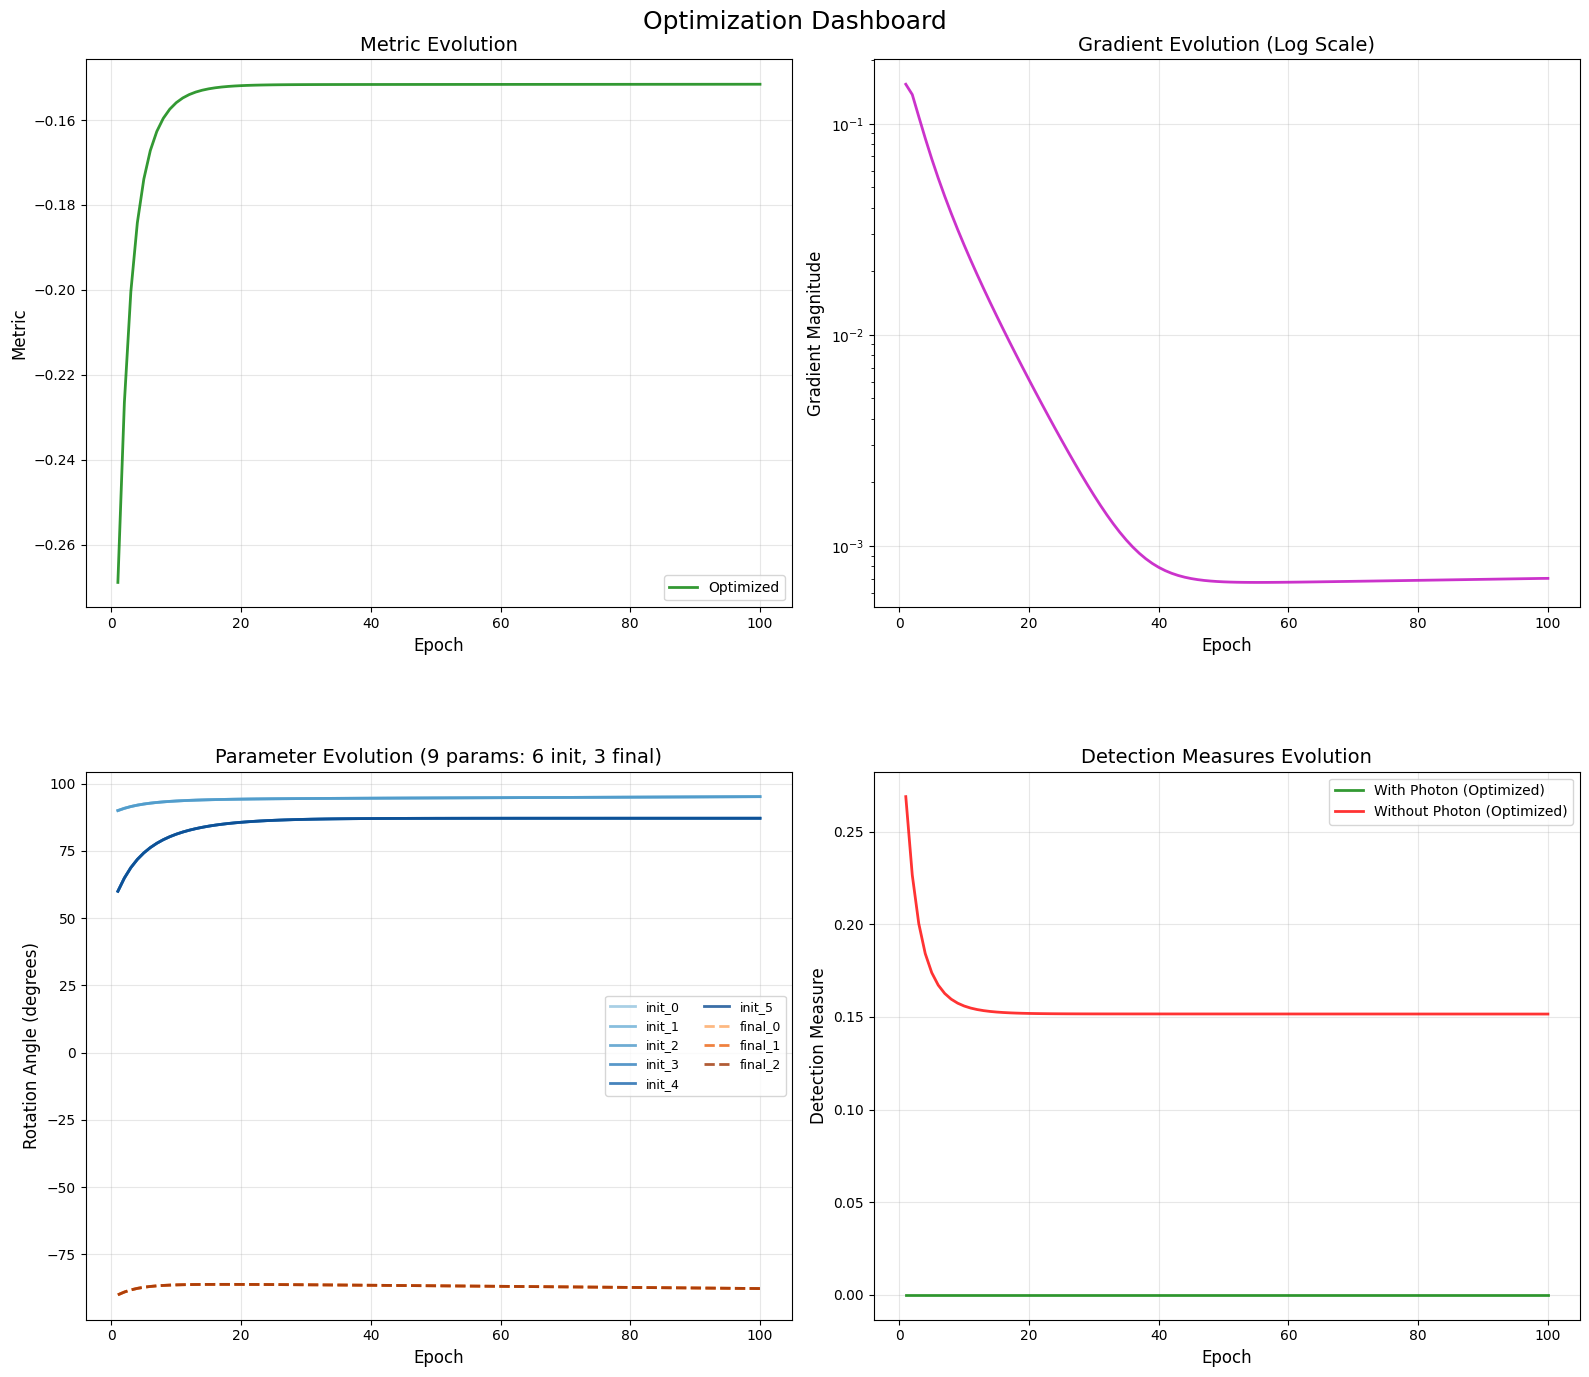

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_00,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()


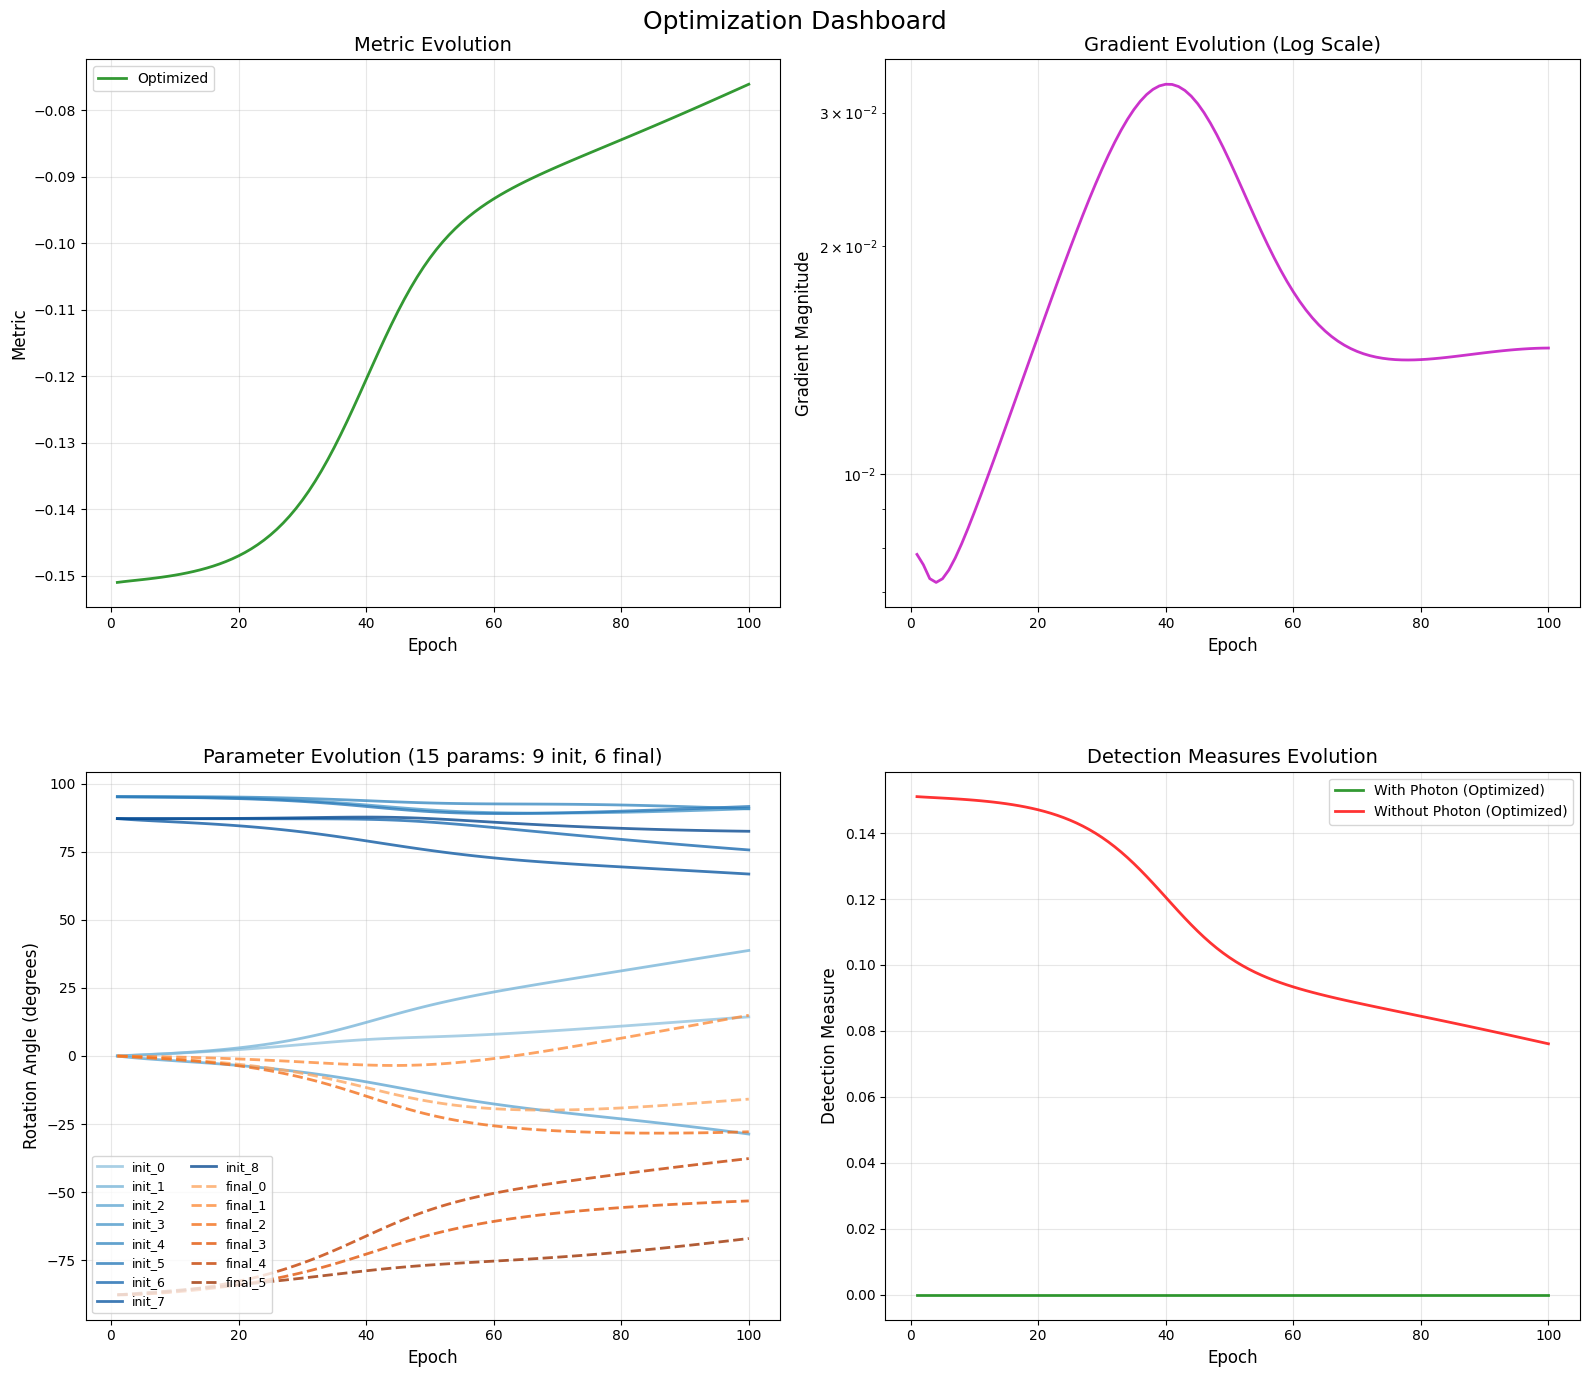

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_11,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()
